# ZShooter ZImager DIQ (based on spie 2026)

In [1]:
%matplotlib inline
from collections import OrderedDict
from contextlib import contextmanager
import importlib.metadata
from math import erf
import logging
import pathlib
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
from astropy.table import Table

import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp

# One visible switch controls the notebook, paper/vector, and presentation styles.
PLOT_MODE = "paper"  # choose: notebook, paper, presentation
PLOT_STYLES = {
    "notebook": "default",
    "paper": "seaborn-v0_8-paper",
    "presentation": "dark_background",
}
plt.style.use(PLOT_STYLES[PLOT_MODE])


def display_and_save_figure(fig, output_stem, *, filename=None, filename_append="", save=True):
    if filename is not None and filename_append:
        raise ValueError("Use filename or filename_append, not both.")
    if filename is None:
        target = pathlib.Path(f"{output_stem}{filename_append}.pdf")
    else:
        target = pathlib.Path(filename)
        if not target.suffix:
            target = target.with_suffix(".pdf")
    if not target.is_absolute():
        target = pathlib.Path(output_dir) / target
    display(fig)
    if save:
        fig.savefig(target, bbox_inches="tight")
    plt.close(fig)
    return target

In [2]:
from zs_scopesim_tools.helpers import (configure_irdb_path, disable_scopesim_top_level_catch, instrument_package_dir,
                                        make_local_output_dir, set_scopesim_log_level, warning_prevent_sync_alt_ra_dec,
                                        ignore_warnings)
from zs_scopesim_tools.plots import plot_resolving_power_echellogram, plot_slit_loss_by_arm, plot_slit_width_loss
from zs_scopesim_tools.validation import (
    build_slit_loss_data, build_slit_width_loss_data,
    effect_name, trace_resolution_diagnostic_table, trace_resolution_summary_display_table, trace_resolution_summary_table
)
ignore_warnings()

In [18]:
def paper_settings():
    return plt.rc_context({
        "font.family": "cmr10",
        "font.size": 13.3,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 13.3,
        "ytick.labelsize": 13.3,
        "legend.fontsize": 13.3,
        "mathtext.fontset": "cm",
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False,
        "pdf.fonttype": 42,
    })

## Run Configuration

Edit this cell first. The notebook is organized so the configuration, source construction, and background toggles are near the calculations that depend on them. The altitude is derived from the requested airmass and RA/Dec are cleared so sky and PSF terms are driven by the quantities that matter for this simulator validation: airmass, seeing, sky brightness, slit, exposure time, and enabled effects.

In [3]:
irdb_path = configure_irdb_path()
set_scopesim_log_level("warning")
zshooter_dir = instrument_package_dir("ZShooter_v2")
output_dir = make_local_output_dir("spie2026")
hide_scopesim_progress = True
disable_scopesim_top_level_catch()

from skycalc_ipy.core import SkyModel, get_cache_dir
SkyModel.REQUEST_TIMEOUT = 60
# print(f"SkyCalc timeout: {SkyModel.REQUEST_TIMEOUT}s; cache: {get_cache_dir()}")

def set_channel_exposure(cmds, *, dit, ndit):
    cmds["!OBS.dit"] = dit
    cmds["!OBS.ndit"] = ndit
    for channel in ("blue", "green", "red", "yj", "h", "k"):
        cmds[f"!OBS.dit_{channel}"] = dit
        cmds[f"!OBS.ndit_{channel}"] = ndit

component_metadata = {"telescope_reflection": {"throughput_group": "telescope", "emission_phase": "pre_disperser"},
                      "ir_blocking_filter_selector": {"throughput_group": "ir_blocking_filter"},
                      }

print(f"Outputs: {output_dir}")

def cmd_value(key, commands=None):
    commands = zs.cmds if commands is None else commands
    commands = commands.cmds if hasattr(commands, "cmds") else commands
    return from_currsys(key, commands)


def display_frame(data, *, columns=None, rename=None, formats=None):
    if isinstance(data, Table):
        view = data[columns] if columns is not None else data
        frame = view.to_pandas()
    else:
        frame = pd.DataFrame(data)
        if columns is not None:
            frame = frame.loc[:, columns]
    if rename:
        frame = frame.rename(columns=rename)
    styler = frame.style.hide(axis="index")
    if formats:
        active_formats = {key: value for key, value in formats.items() if key in frame.columns}
        styler = styler.format(active_formats, na_rep="--")
    display(styler)


def compact_range(minimum, maximum, digits=1):
    if not np.isfinite(minimum) or not np.isfinite(maximum):
        return "--"
    if np.isclose(minimum, maximum, rtol=1e-4, atol=10**-digits):
        return f"{minimum:.{digits}f}"
    return f"{minimum:.{digits}f}-{maximum:.{digits}f}"

def show_run():
    code_revision = subprocess.run(["git", "-C", str(pathlib.Path.cwd()), "describe", "--always", "--dirty"], check=True, capture_output=True, text=True).stdout.strip()
    irdb_revision = subprocess.run(["git", "-C", str(irdb_path), "describe", "--always", "--dirty"], check=True, capture_output=True, text=True).stdout.strip()
    run_card = Table(rows=[
        {"quantity": "instrument", "value": "ZShooter_v2 SPEC", "why_it_matters": "loads the release IRDB model"},
        {"quantity": "zs-scopesim revision", "value": code_revision, "why_it_matters": "identifies the notebook and package implementation"},
        {"quantity": "ScopeSim version", "value": importlib.metadata.version("ScopeSim"), "why_it_matters": "identifies the simulation engine"},
        {"quantity": "IRDB revision", "value": irdb_revision, "why_it_matters": "identifies the configured instrument data"},
        {"quantity": "airmass", "value": cmd_value("!OBS.airmass"), "why_it_matters": "sets atmospheric path, dispersion, and sky"},
        {"quantity": "altitude [deg]", "value": cmd_value("!OBS.alt"), "why_it_matters": "derived from airmass for ScopeSim AltAz context"},
        {"quantity": "RA/Dec", "value": f"{cmd_value('!OBS.ra')}/{cmd_value('!OBS.dec')}", "why_it_matters": "cleared so they do not override airmass"},
        {"quantity": "seeing [arcsec]", "value": cmd_value("!OBS.seeing"), "why_it_matters": "natural-seeing PSF scale"},
        {"quantity": "sky brightness", "value": cmd_value("!OBS.brightness"), "why_it_matters": "SkyCalc continuum/line brightness preset"},
        {"quantity": "command telescope area", "value": cmd_value("!TEL.area", cmd), "why_it_matters": "pre-train default; should be replaced by optical-train derived area"},
        {"quantity": "train telescope area", "value": cmd_value("!TEL.area"), "why_it_matters": "derived from the active Keck mirror SurfaceList and used by FOV/source scaling"},
        {"quantity": "VIS slit [arcsec]", "value": cmd_value("!INST.vis_curr_slit"), "why_it_matters": "source throughput and resolution"},
        {"quantity": "NIR slit [arcsec]", "value": cmd_value("!INST.nir_curr_slit"), "why_it_matters": "source throughput and resolution"},
        {"quantity": "spectral resolving power guardrail", "value": cmd_value("!SIM.spectral.spectral_resolution"), "why_it_matters": "internal spectral work grid / sky sampling guardrail"},
        {"quantity": "DIT x NDIT", "value": f"{cmd_value('!OBS.dit_green')} x {cmd_value('!OBS.ndit_green')}", "why_it_matters": "per-channel detector exposure; total is DIT*NDIT"},
        {"quantity": "pupil angle [deg]", "value": cmd_value("!OBS.pupil_angle"), "why_it_matters": "source-pair orientation used below"},
    ])
    display_frame(run_card, rename={"why_it_matters": "why it matters"})
    return run_card

Outputs: /Users/jibailey/src/zs-scopesim/notebooks/spie2026


In [52]:
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
cmd["!OBS.airmass"] = 1.1
cmd["!OBS.seeing"] = 0.65
cmd["!OBS.brightness"] = "grey"
cmd["!OBS.pupil_angle"] = 0.0
set_channel_exposure(cmd, dit=1800, ndit=2)
cmd["!INST.vis_curr_slit"] = 0.7 # 0.33
cmd["!INST.nir_curr_slit"] = 0.7 # 0.33
cmd["!INST.include_diffuse_emmisivity"] = False
cmd["!SIM.sub_pixel.flag"] = True

warning_prevent_sync_alt_ra_dec(cmd)

zs = sim.OpticalTrain(cmd)
show_run();


astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.


quantity,value,why it matters
instrument,ZShooter_v2 SPEC,loads the release IRDB model
zs-scopesim revision,49b94a5-dirty,identifies the notebook and package implementation
ScopeSim version,0.11.5a3,identifies the simulation engine
IRDB revision,04a07f6,identifies the configured instrument data
airmass,1.100000,"sets atmospheric path, dispersion, and sky"
altitude [deg],65.380023,derived from airmass for ScopeSim AltAz context
RA/Dec,None/None,cleared so they do not override airmass
seeing [arcsec],0.650000,natural-seeing PSF scale
sky brightness,grey,SkyCalc continuum/line brightness preset
command telescope area,0,pre-train default; should be replaced by optical-train derived area


## Trace Geometry And Resolution Scale

This detector-facing diagnostic samples the loaded spectral traces on the active image planes. The table gives compact channel ranges; the first map shows local resolving power from the trace geometry and detector pixel scale, while the second map shows the corresponding spectral-element sampling width. Blank pixels are off trace. The plotted samples are kept only where the sampled slit footprint is fully on detector; the trace catalog below is the check for the total loaded order count. Detector rotation is part of the trace geometry being checked; `detector_pad` is legacy metadata and is not applied to the optical trace geometry.

,ch,id,orders,wave nm,slit,spec FWHM pix,disp nm/pix,R k,resel pix,seeing
0,B,0,34,307-431,"0.70""",4.46,0.0037-0.0056,17.0-19.3,20.1-21.5,"0.73""/4.7 pix"
1,G,1,30,426-656,"0.70""",4.46,0.0051-0.0088,16.5-20.0,18.5-20.2,"0.68""/4.3 pix"
2,R,2,20,645-994,"0.70""",4.46,0.0074-0.0138,15.8-20.7,17.0-18.6,"0.63""/4.0 pix"
3,YJ,3,24,945-1343,"0.70""",4.46,0.0112-0.0180,16.4-19.8,16.0-17.2,"0.58""/3.7 pix"
4,H,4,11,1474-1872,"0.70""",4.46,0.0168-0.0257,16.0-20.6,15.0-15.7,"0.54""/3.4 pix"
5,K,5,8,1973-2474,"0.70""",4.46,0.0215-0.0346,15.6-21.1,14.2-14.9,"0.51""/3.3 pix"


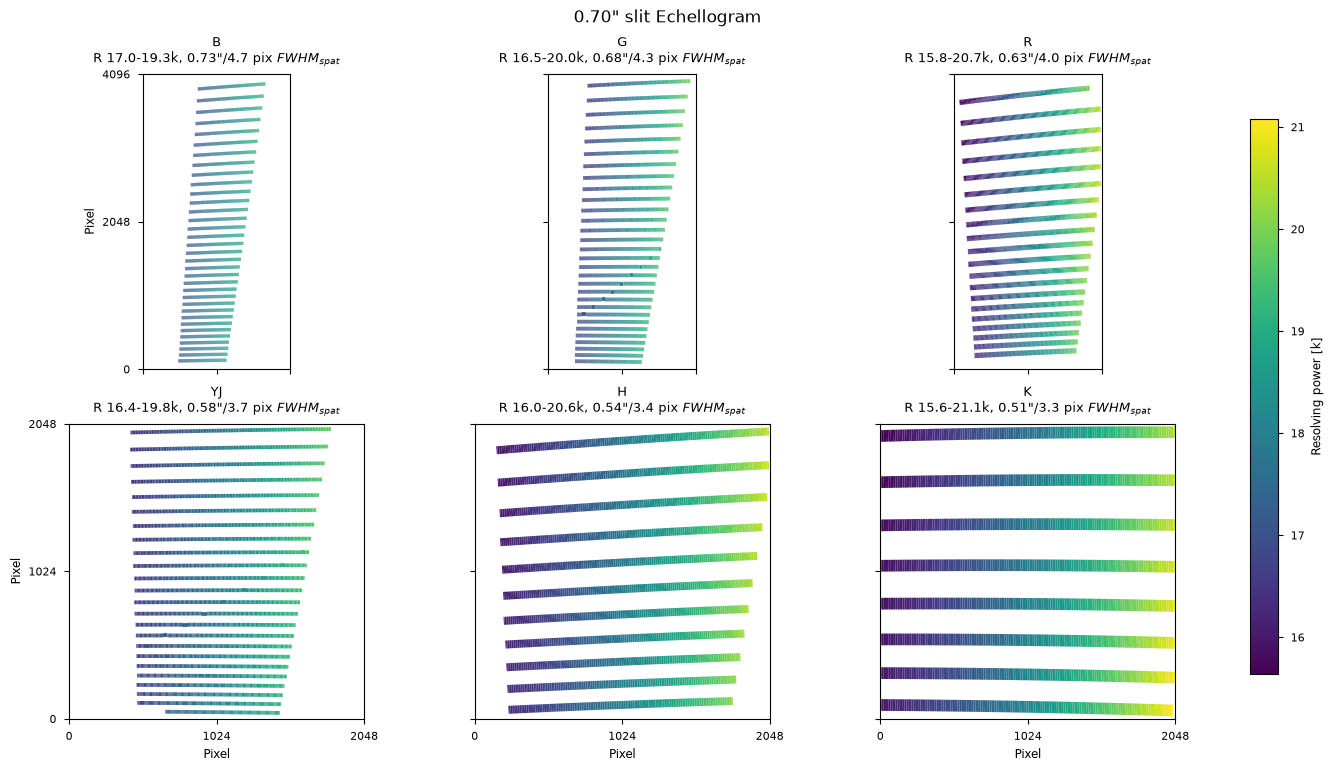

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/resolving_power_070_slit.pdf')

In [55]:
trace_resolution = trace_resolution_diagnostic_table(zs)
trace_resolution_summary = trace_resolution_summary_table(trace_resolution)
display(trace_resolution_summary_display_table(trace_resolution_summary))

fig, axes = plot_resolving_power_echellogram(trace_resolution, trace_width_fraction= (.4, .4,.4, .3, .3, .3), max_display_samples_per_trace=128)
fig.suptitle('0.70" slit Echellogram')
display_and_save_figure(fig, "resolving_power_070_slit")

## Slit Loss, Seeing, AO Design Curves, And Atmospheric Dispersion

These plots are diagnostics for the optical geometry rather than extracted data products. The first plot uses color for seeing/AO, dash pattern for slit choice, opacity for airmass, and short tick marks on the line for ADC off. Line weight is reserved for the fully current observing combination. The slit legend uses `*` for the selected VIS slit and `^` for the selected NIR slit when a selected slit is one of the plotted extrema; when both arms use the same non-extremal selected slit, that shared style is labeled `Selected slit`. The second plot isolates PSF loss as a function of slit width. Legend labels pair VIS/NIR wavelengths by construction, for example `0.65" NS, 500/1250 nm`; if that pairing breaks, the plot should fail instead of silently changing meaning.


Text(0.5, 0.98, 'Configured slit transmission')

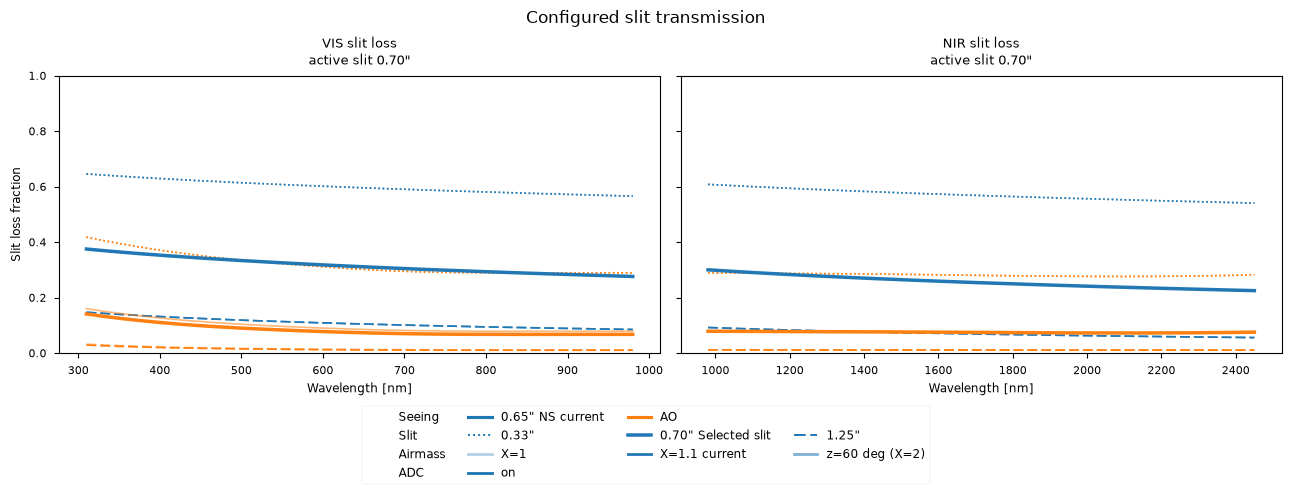

In [56]:
SLIT_LOSS_SAMPLES = 160
SLIT_LOSS_GRID_STEP = 0.04 * u.arcsec

slit_loss_data = build_slit_loss_data(zs, n_wave=SLIT_LOSS_SAMPLES, slit_length=10 * u.arcsec, grid_step=SLIT_LOSS_GRID_STEP)
fig, axes = plot_slit_loss_by_arm(slit_loss_data, show_airmass_states=True, show_adc_states=False)
fig.suptitle("Configured slit transmission")


astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.


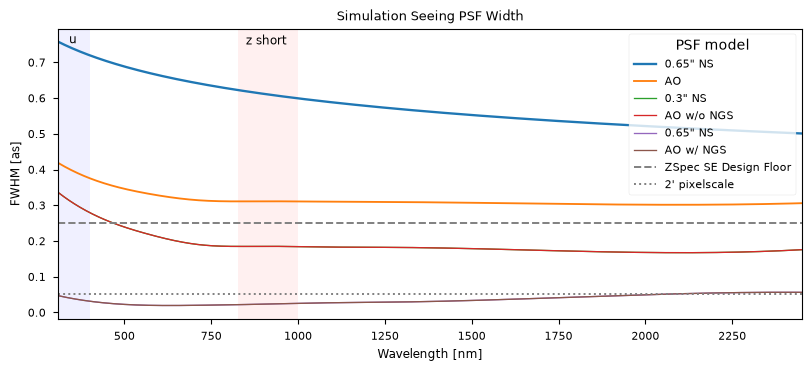

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/zimager_seeing_budget.pdf')

In [57]:
psf_wave_nm = np.linspace(310, 2450, 700) * u.nm
fig, ax = plt.subplots(figsize=(8.0, 3.6), constrained_layout=True)
for mode_name, mode in slit_loss_data["psf_modes"].items():
    fwhm = mode["fwhm_func"](psf_wave_nm, psf_zenith, psf_seeing).to_value(u.arcsec)
    ax.plot(psf_wave_nm.to_value(u.nm), fwhm, label=mode["label"], linewidth=plt.rcParams["lines.linewidth"] * (1.2 if mode.get("current", False) else 0.95))

cmd["!OBS.seeing"] = 0.3
cmd['!ATMO.ao_table'] = 'ao_table_noNGS.dat'
cmd['!ATMO.ao_enabled'] = True

zs = sim.OpticalTrain(cmd)
slit_loss_data = build_slit_loss_data(zs, n_wave=SLIT_LOSS_SAMPLES, slit_length=10 * u.arcsec, grid_step=SLIT_LOSS_GRID_STEP)
psf_seeing = slit_loss_data["seeing_arcsec"]
psf_zenith = slit_loss_data["current_zenith_angle_deg"].to(u.deg)

# fig, ax = plt.subplots(figsize=(8.0, 3.6), constrained_layout=True)
for mode_name, mode in slit_loss_data["psf_modes"].items():
    fwhm = mode["fwhm_func"](psf_wave_nm, psf_zenith, psf_seeing).to_value(u.arcsec)
    ax.plot(psf_wave_nm.to_value(u.nm), fwhm, label='AO w/o NGS' if mode["label"]=='AO' else mode["label"], linewidth= 0.95)


cmd["!OBS.seeing"] = 0.65
cmd['!ATMO.ao_table'] = 'ao_table_ngs.dat'
cmd['!ATMO.ao_enabled'] = True
zs = sim.OpticalTrain(cmd)
slit_loss_data = build_slit_loss_data(zs, n_wave=SLIT_LOSS_SAMPLES, slit_length=10 * u.arcsec, grid_step=SLIT_LOSS_GRID_STEP)
psf_seeing = slit_loss_data["seeing_arcsec"]
psf_zenith = slit_loss_data["current_zenith_angle_deg"].to(u.deg)

for mode_name, mode in slit_loss_data["psf_modes"].items():
    fwhm = mode["fwhm_func"](psf_wave_nm, psf_zenith, psf_seeing).to_value(u.arcsec)
    ax.plot(psf_wave_nm.to_value(u.nm), fwhm, label='AO w/ NGS' if mode["label"]=='AO' else mode["label"], linewidth= 0.95)

plt.axhline(.25, linestyle='--', color='grey', label='ZSpec SE Design Floor')

plt.axhline(120/2304, linestyle=':', color='grey', label="2' pixelscale")

ax.axvspan(310, 400, color="blue", alpha=0.06, lw=0)
ax.axvspan(826, 1000, color="red", alpha=0.06, lw=0)
ax.text(np.sqrt(310*400), 0.98, 'u', transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize="small", color=plt.rcParams["text.color"])
ax.text(np.sqrt(826*1000), 0.98, 'z short', transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize="small", color=plt.rcParams["text.color"])

ax.set_xlim(psf_wave_nm.min().value, psf_wave_nm.max().value)
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("FWHM [as]")
ax.set_title("Simulation Seeing PSF Width")
ax.legend(title="PSF model")
display_and_save_figure(fig, "zimager_seeing_budget", save=True)

In [58]:
slit_width_rows = []
for arm_name, arm in slit_width_loss_data["arms"].items():
    slit_widths = arm["slit_widths_arcsec"].to_value(u.arcsec)
    current_slit = arm["current_slit_width_arcsec"].to_value(u.arcsec)
    for curve in arm["curves"].values():
        slit_width_rows.append({
            "arm": arm_name,
            "PSF / ADC case": curve["psf_mode"],
            "wavelength [nm]": curve["wavelength_nm"],
            "active slit [arcsec]": current_slit,
            "transmission at active slit": np.interp(current_slit, slit_widths, curve["throughput"]),
            "loss at active slit": np.interp(current_slit, slit_widths, curve["loss"]),
        })
display_frame(slit_width_rows,
    formats={
        "wavelength [nm]": "{:.0f}",
        "active slit [arcsec]": "{:.2f}",
        "transmission at active slit": "{:.3f}",
        "loss at active slit": "{:.3f}",
    }
)


arm,PSF / ADC case,wavelength [nm],active slit [arcsec],transmission at active slit,loss at active slit
VIS,no_ao,350,0.70,0.630,0.370
VIS,no_ao,500,0.70,0.661,0.339
VIS,no_ao,750,0.70,0.692,0.308
VIS,no_ao,950,0.70,0.713,0.287
VIS,ao,350,0.70,0.853,0.147
VIS,ao,500,0.70,0.892,0.108
VIS,ao,750,0.70,0.917,0.083
VIS,ao,950,0.70,0.918,0.082
NIR,no_ao,1000,0.70,0.720,0.280
NIR,no_ao,1250,0.70,0.735,0.265
